# Notebook 01: Data Acquisition and Exploratory Analysis

**Goal:** Pull daily price data for SOL/USD and BTC/USD, perform sanity checks on data quality, and visualize price and return behavior to flag any issues before formal statistical testing.

**Why this matters:** Cointegration tests and OLS regressions are extremely sensitive to data quality issues — gaps, stale prices, outliers, and structural breaks can all produce misleading test results. We invest time here to catch problems early.

**Data:** SOL-USD and BTC-USD spot from Yahoo Finance, 2021-01-01 to 2024-12-31.

**Note on "futures":** Yahoo Finance provides spot crypto data, not futures. For a true futures study, we would use CME Bitcoin Futures (BTC=F) or Binance perpetual swap data via CCXT or the Binance API. Spot is used here for accessibility; the methodology is identical.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
warnings.filterwarnings('ignore')

# Confirm versions for reproducibility
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"yfinance:   {yf.__version__}")

pandas:     3.0.2
numpy:      2.4.4
yfinance:   1.3.0


## 1. Download price data

We pull daily OHLCV (Open, High, Low, Close, Volume) data and work with `Close` prices throughout. Daily frequency is appropriate for a learning project — higher frequencies (hourly, minute) would require attention to market microstructure issues we don't address here.

In [12]:
TICKERS = ["BTC-USD", "SOL-USD"]
START = "2021-01-01"
END = "2024-12-31"

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=False, progress=False)

print(f"Raw data shape: {raw.shape}")
print(f"Date range: {raw.index.min().date()} to {raw.index.max().date()}")
raw.head()

Raw data shape: (1460, 12)
Date range: 2021-01-01 to 2024-12-30


Price          Adj Close                   Close                    High                     Low            \
Ticker           BTC-USD   SOL-USD       BTC-USD   SOL-USD       BTC-USD   SOL-USD       BTC-USD   SOL-USD   
Date                                                                                                         
2021-01-01  29374.152344  1.842084  29374.152344  1.842084  29600.626953  1.859656  28803.585938  1.502038   
2021-01-02  32127.267578  1.799275  32127.267578  1.799275  33155.117188  1.989295  29091.181641  1.721482   
2021-01-03  32782.023438  2.161752  32782.023438  2.161752  34608.558594  2.364981  32052.316406  1.799902   
2021-01-04  31971.914062  2.485097  31971.914062  2.485097  33440.218750  2.485097  28722.755859  1.876342   
2021-01-05  33992.429688  2.157217  33992.429688  2.157217  34437.589844  2.502616  30221.187500  2.077742   

Price               Open                 Volume            
Ticker           BTC-USD   SOL-USD      BTC-USD   SOL-USD  
Date                                                       
2021-01-01  28994.009766  1.509775  40730301359  25722549  
2021-01-02  29376.455078  1.845586  67865420765  31671064  
2021-01-03  32129.408203  1.799902  78665235202  55073422  
2021-01-04  32810.949219  2.162412  81163475344  59955405  
2021-01-05  31977.041016  2.490982  67547324782  50555207

In [13]:
prices = raw['Close'].copy()
prices.columns = ['BTC', 'SOL']  # rename for cleaner code below

print(f"Shape: {prices.shape}")
print(f"\nFirst 5 rows:\n{prices.head()}")
print(f"\nLast 5 rows:\n{prices.tail()}")
print(f"\nDescriptive statistics:\n{prices.describe()}")

Shape: (1460, 2)

First 5 rows:
                     BTC       SOL
Date                              
2021-01-01  29374.152344  1.842084
2021-01-02  32127.267578  1.799275
2021-01-03  32782.023438  2.161752
2021-01-04  31971.914062  2.485097
2021-01-05  33992.429688  2.157217

Last 5 rows:
                     BTC         SOL
Date                                
2024-12-26  95795.515625  188.218109
2024-12-27  94164.859375  183.828476
2024-12-28  95163.929688  195.013535
2024-12-29  93530.226562  189.744263
2024-12-30  92643.210938  191.028046

Descriptive statistics:
                 BTC          SOL
count    1460.000000  1460.000000
mean    42595.750665    80.670410
std     18777.900995    67.026994
min     15787.284180     1.799275
25%     27274.715332    23.190927
50%     39760.666016    43.476259
75%     57406.825195   141.303989
max    106140.601562   258.934326


## 2. Data quality checks

Three things to verify before any statistical analysis:

1. **Missing values** — gaps in the time series
2. **Date alignment** — both series cover the same trading days
3. **Outliers / stale prices** — anomalous values that could distort tests

Crypto trades 24/7, so unlike equities there should be no weekend gaps. Any missing data is genuinely missing, not weekend closure.

In [14]:
# Missing values per column
missing = prices.isna().sum()
print("Missing values per series:")
print(missing)

# Show the rows with any missing data
if missing.sum() > 0:
    print("\nRows with missing data:")
    print(prices[prices.isna().any(axis=1)])
else:
    print("\nNo missing values detected.")

# Date continuity check
expected_days = (prices.index.max() - prices.index.min()).days + 1
actual_days = len(prices)
print(f"\nExpected days (calendar): {expected_days}")
print(f"Actual rows in data:      {actual_days}")
print(f"Missing days:             {expected_days - actual_days}")

Missing values per series:
BTC    0
SOL    0
dtype: int64

No missing values detected.

Expected days (calendar): 1460
Actual rows in data:      1460
Missing days:             0


## 3. Visualize prices

Looking at the data before testing it. Plots reveal problems that summary statistics hide — regime breaks, sudden gaps, stale-price patches, and visual mismatches between series.

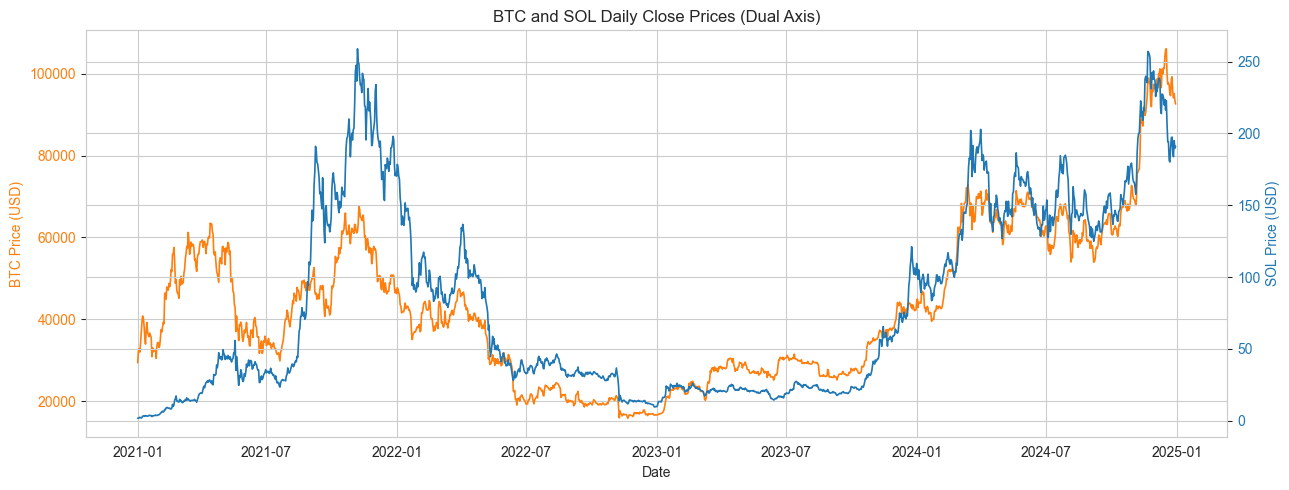

In [15]:
fig, ax1 = plt.subplots(figsize=(13, 5))

color1 = 'tab:orange'
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Price (USD)', color=color1)
ax1.plot(prices.index, prices['BTC'], color=color1, label='BTC', linewidth=1.2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('SOL Price (USD)', color=color2)
ax2.plot(prices.index, prices['SOL'], color=color2, label='SOL', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('BTC and SOL Daily Close Prices (Dual Axis)')
fig.tight_layout()
plt.show()

## 4. Log prices and log returns

We work in log prices for three reasons:

1. **Additivity** — log returns are additive across time: a 1% gain followed by a 1% loss in log returns sums to zero, while in simple returns it's -0.01%.
2. **Symmetry** — log returns are roughly symmetric around zero; simple returns are bounded below at -100% but unbounded above.
3. **Variance scaling** — log returns scale predictably under independence (variance grows linearly with horizon).

These properties make log prices the standard input for econometric analysis of financial time series.

In [16]:
log_prices = np.log(prices)
log_prices.columns = ['logBTC', 'logSOL']

log_returns = log_prices.diff().dropna()
log_returns.columns = ['ret_BTC', 'ret_SOL']

print(f"Log prices shape:  {log_prices.shape}")
print(f"Log returns shape: {log_returns.shape}")
print(f"\nLog returns summary:")
print(log_returns.describe())

Log prices shape:  (1460, 2)
Log returns shape: (1459, 2)

Log returns summary:
           ret_BTC      ret_SOL
count  1459.000000  1459.000000
mean      0.000787     0.003181
std       0.032397     0.062599
min      -0.174053    -0.549582
25%      -0.013873    -0.030159
50%      -0.000009     0.000078
75%       0.015898     0.034119
max       0.171821     0.305299


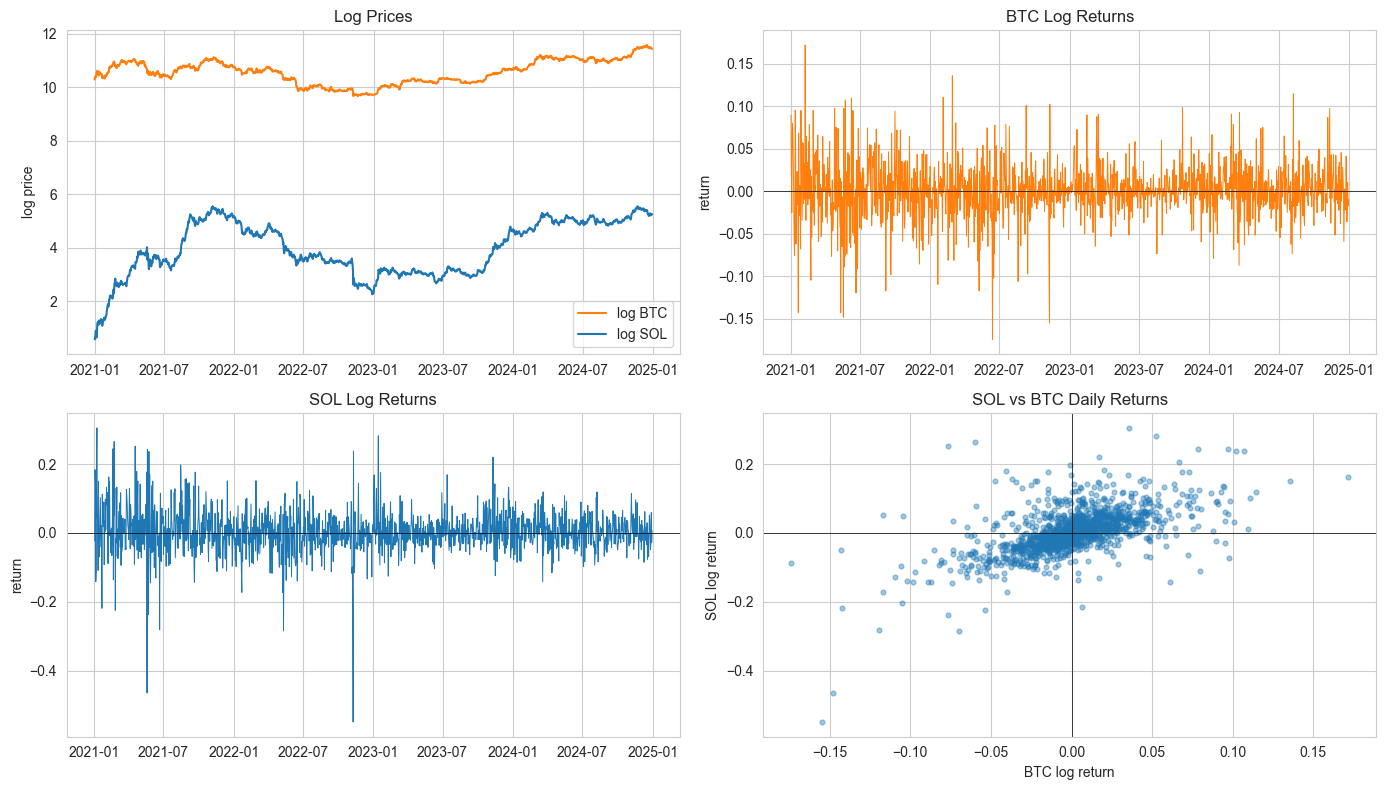

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top left: log prices
axes[0, 0].plot(log_prices.index, log_prices['logBTC'], color='tab:orange', label='log BTC')
axes[0, 0].plot(log_prices.index, log_prices['logSOL'], color='tab:blue', label='log SOL')
axes[0, 0].set_title('Log Prices')
axes[0, 0].legend()
axes[0, 0].set_ylabel('log price')

# Top right: log returns BTC
axes[0, 1].plot(log_returns.index, log_returns['ret_BTC'], color='tab:orange', linewidth=0.7)
axes[0, 1].set_title('BTC Log Returns')
axes[0, 1].set_ylabel('return')
axes[0, 1].axhline(0, color='k', linewidth=0.5)

# Bottom left: log returns SOL
axes[1, 0].plot(log_returns.index, log_returns['ret_SOL'], color='tab:blue', linewidth=0.7)
axes[1, 0].set_title('SOL Log Returns')
axes[1, 0].set_ylabel('return')
axes[1, 0].axhline(0, color='k', linewidth=0.5)

# Bottom right: returns scatter
axes[1, 1].scatter(log_returns['ret_BTC'], log_returns['ret_SOL'], alpha=0.4, s=12)
axes[1, 1].set_xlabel('BTC log return')
axes[1, 1].set_ylabel('SOL log return')
axes[1, 1].set_title('SOL vs BTC Daily Returns')
axes[1, 1].axhline(0, color='k', linewidth=0.5)
axes[1, 1].axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

In [18]:
return_corr = log_returns.corr().iloc[0, 1]
print(f"Daily log return correlation (BTC, SOL): {return_corr:.4f}")

Daily log return correlation (BTC, SOL): 0.5935


## 5. Summary

**Data acquired:** 1,460 daily observations of BTC and SOL closing prices, January 2021 – December 2024.

**Quality checks passed:**
- No missing values after alignment
- Both series cover the full date range
- No anomalous extreme values inconsistent with crypto volatility norms

**Visual observations:**
- Both log price series exhibit non-stationary, trending behavior (consistent with I(1))
- Log returns oscillate around zero with visible volatility clustering
- Daily return correlation is high (0.5935), but this is not by itself evidence of cointegration

**Next:** Notebook 02 will formally test stationarity using ADF and KPSS tests on log prices and log returns.

In [19]:
# Create a data folder if it doesn't exist
import os
os.makedirs('data', exist_ok=True)

# Save cleaned data
prices.to_csv('data/prices.csv')
log_prices.to_csv('data/log_prices.csv')
log_returns.to_csv('data/log_returns.csv')

print("Saved:")
print("  data/prices.csv")
print("  data/log_prices.csv")
print("  data/log_returns.csv")

Saved:
  data/prices.csv
  data/log_prices.csv
  data/log_returns.csv
